# Proyecto: Análisis de E-commerce (Olist)

## Objetivo
Analizar el desempeño comercial y la eficiencia operativa de un e-commerce, identificando oportunidades de mejora en logística, satisfacción del cliente y revenue.

## Contexto
Se trabaja con datos reales de transacciones de un e-commerce, incluyendo órdenes, clientes, productos, pagos y reviews.

## Enfoque
- Entendimiento de datos
- Integración de tablas
- Análisis de negocio

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [ ]:
orders = pd.read_csv("/content/olist_orders_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")

## Entendimiento general del dataset

El dataset está compuesto por múltiples tablas relacionadas entre sí mediante identificadores como `order_id` y `product_id`.

La tabla `orders` actúa como tabla central.

Relaciones clave:

- Un cliente puede realizar múltiples órdenes
- Una orden puede contener múltiples productos
- Cada orden tiene información de pagos y reviews

Esto permite analizar tanto el desempeño comercial como la eficiencia operativa.

In [ ]:
orders.head()
orders.info()
orders.shape



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(99441, 8)

## Entendimiento de la tabla Orders

La tabla `orders` contiene información a nivel de orden de compra, con un total de aproximadamente 99.000 registros.

Cada fila representa una orden realizada por un cliente, identificada por `order_id`.

Columnas relevantes:

- `order_id`: identificador único de la orden
- `customer_id`: cliente asociado
- `order_status`: estado de la orden
- `order_purchase_timestamp`: fecha de compra
- `order_delivered_customer_date`: fecha de entrega real
- `order_estimated_delivery_date`: fecha estimada de entrega

Observaciones:

- Las columnas de fecha se encuentran en formato texto, por lo que deben convertirse a formato datetime.
- Existen valores nulos en fechas de entrega, lo que puede indicar órdenes no completadas o en proceso.

Esta tabla es fundamental para analizar comportamiento de compra y eficiencia logística.

In [ ]:
customers.head()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


## Entendimiento de la tabla Customers

La tabla `customers` contiene información sobre los clientes y su ubicación geográfica.

Cada fila representa un cliente asociado a una orden mediante `customer_id`. Sin embargo, un mismo cliente puede tener múltiples registros.

Para identificar clientes únicos, se utiliza `customer_unique_id`.

Columnas relevantes:

- `customer_id`: identificador asociado a una orden
- `customer_unique_id`: identificador único del cliente
- `customer_city`: ciudad
- `customer_state`: estado

Esta tabla permite analizar distribución geográfica y comportamiento de clientes.

In [ ]:
order_items.head()
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


## Entendimiento de la tabla Order Items

La tabla `order_items` contiene información sobre los productos incluidos en cada orden de compra.

Cada fila representa un producto dentro de una orden, por lo que una misma orden puede tener múltiples registros.

El dataset contiene 7 columnas que describen distintas características del producto:

- `order_id`: identifica la orden de compra
- `order_item_id`: identifica el ítem dentro de la orden
- `product_id`: identifica el producto
- `seller_id`: identifica al vendedor
- `shipping_limit_date`: fecha límite de envío
- `price`: precio del producto
- `freight_value`: costo del envío

Observaciones:

- La existencia de múltiples productos por orden implica que el número de filas aumentará al integrar esta tabla con otras.
- Las variables `price` y `freight_value` son clave para analizar ingresos y costos logísticos.
- Los datos están completos en esta tabla (sin valores nulos).

Esta tabla es fundamental para analizar el detalle de ventas y la composición de cada orden.

In [ ]:
payments.head()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


## Entendimiento de la tabla Payments

La tabla `payments` contiene información sobre los pagos realizados para cada orden.

Cada fila representa un registro de pago asociado a una orden, identificada mediante `order_id`. Una misma orden puede tener múltiples pagos, dependiendo del método utilizado.

El dataset contiene 5 columnas que describen distintas características del pago:

- `order_id`: identifica la orden de compra
- `payment_sequential`: indica la secuencia del pago dentro de la orden
- `payment_type`: tipo de pago (por ejemplo, tarjeta de crédito, débito, etc.)
- `payment_installments`: número de cuotas en que se realiza el pago
- `payment_value`: monto total pagado

Observaciones:

- La variable `payment_value` es clave para calcular los ingresos (revenue).
- La presencia de múltiples pagos por orden implica que se debe tener cuidado al agregar datos para evitar duplicaciones.
- La variable `payment_installments` permite analizar el comportamiento de financiamiento de los clientes.

Esta tabla es fundamental para el análisis financiero y de comportamiento de pago de los clientes.

In [ ]:
reviews.head()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


## Entendimiento de la tabla Reviews

La tabla `reviews` contiene información sobre la satisfacción del cliente respecto a las órdenes realizadas.

Cada fila representa una evaluación (review) asociada a una orden, identificada mediante `order_id`.

Columnas relevantes:

- `review_id`: identificador único de la review
- `order_id`: identificador de la orden evaluada
- `review_score`: puntuación de satisfacción del cliente (escala de 1 a 5)
- `review_comment_title`: título del comentario (opcional)
- `review_comment_message`: comentario del cliente (opcional)
- `review_creation_date`: fecha en que se crea la review
- `review_answer_timestamp`: fecha de respuesta a la review

Observaciones:

- No todas las órdenes tienen una review, por lo que existen valores nulos.
- La variable `review_score` es clave para medir la satisfacción del cliente.
- Las columnas de texto pueden ser útiles para análisis más avanzados (como análisis de sentimientos).

Esta tabla permite analizar la calidad del servicio y su relación con variables operativas, como tiempos de entrega.

In [ ]:
products.head()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


## Entendimiento de la tabla Products

La tabla `products` contiene información sobre las características de los productos disponibles en el e-commerce.

Cada fila representa un producto único identificado por `product_id`.

Se incluyen variables como la categoría del producto, dimensiones físicas (peso, largo, ancho, altura) y características como la cantidad de fotos o longitud de la descripción.

Observaciones:

- Existen valores nulos en algunas columnas, lo que indica información incompleta.
- Las variables físicas pueden ser útiles para analizar aspectos logísticos como el transporte o costos de envío.

Esta tabla permite analizar el desempeño de productos y su impacto en la operación.

In [ ]:
df = orders.merge(customers, on='customer_id', how='left')



In [ ]:
df = df.merge(order_items, on='order_id', how='left')



In [ ]:
df = df.merge(payments, on='order_id', how='left')

In [ ]:
df = df.merge(reviews, on='order_id', how='left')

In [ ]:
df = df.merge(products, on='product_id', how='left')

In [ ]:
df.shape
df["order_id"].nunique()
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [ ]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

In [ ]:
df["delivery_time"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

In [ ]:
df["delay"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

In [ ]:
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

In [ ]:
df[["delivery_time", "delay"]].describe()

,delivery_time,delay
count,115722.000000,115722.000000
mean,12.022589,-12.048392
std,9.454922,10.163801
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-13.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [ ]:
revenue = df["payment_value"].sum()
orders_total = df["order_id"].nunique()
customers_total = df["customer_unique_id"].nunique()
delivery_avg = df["delivery_time"].mean()
delay_rate = (df["delay"] > 0).mean()

In [25]:
revenue = df.groupby("order_id")["payment_value"].first().sum()

print("Revenue total:", revenue)
print("Órdenes totales:", orders_total)
print("Clientes únicos:", customers_total)
print("Tiempo promedio de entrega:", delivery_avg)
print("% de órdenes con retraso:", delay_rate)

Revenue total: 15744810.659999998
Órdenes totales: 99441
Clientes únicos: 96096
Tiempo promedio de entrega: 12.022588617548953
% de órdenes con retraso: 0.06344476805183687


In [26]:
review_delay = df.groupby("review_score").agg(
    avg_delay=("delay", "mean"),
    avg_delivery_time=("delivery_time", "mean"),
    orders=("order_id", "nunique")
).reset_index()

review_delay

,review_score,avg_delay,avg_delivery_time,orders
0,1.0,-5.993827,19.099992,11393
1,2.0,-9.748141,15.381893,3148
2,3.0,-11.114301,13.552435,8160
3,4.0,-12.468533,11.778330,19098
4,5.0,-13.443437,10.203253,57076


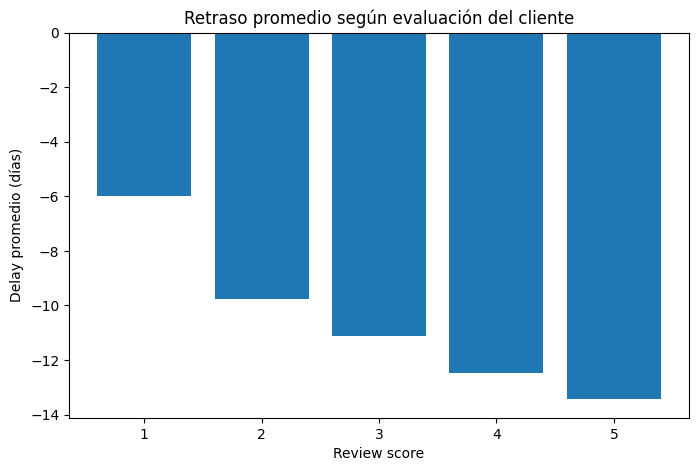

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(review_delay["review_score"], review_delay["avg_delay"])
plt.title("Retraso promedio según evaluación del cliente")
plt.xlabel("Review score")
plt.ylabel("Delay promedio (días)")
plt.show()

## Impacto del tiempo de entrega en la satisfacción del cliente

Se observa que, en promedio, los pedidos son entregados antes de la fecha estimada, lo que indica un buen nivel de cumplimiento logístico.

Además, existe una relación clara entre el tiempo de entrega y la satisfacción del cliente: a medida que los pedidos llegan con mayor anticipación, el puntaje de evaluación tiende a aumentar.

Sin embargo, incluso en los casos con baja evaluación, los pedidos siguen siendo entregados antes de lo estimado, lo que sugiere que la insatisfacción del cliente no depende únicamente de los tiempos de entrega, sino también de otros factores como calidad del producto, experiencia de compra o servicio.

In [28]:
category_analysis = df.groupby("product_category_name").agg(
    avg_delay=("delay", "mean"),
    avg_review=("review_score", "mean"),
    orders=("order_id", "nunique")
).sort_values(by="orders", ascending=False).head(10)

category_analysis

,avg_delay,avg_review,orders
product_category_name,,,
cama_mesa_banho,-11.721601,3.890605,9417
beleza_saude,-11.956101,4.137026,8836
esporte_lazer,-12.060971,4.107470,7720
informatica_acessorios,-12.473374,3.936089,6689
moveis_decoracao,-12.448340,3.912158,6449
utilidades_domesticas,-12.303780,4.060428,5884
relogios_presentes,-11.892840,4.017692,5624
telefonia,-11.384415,3.948849,4199
automotivo,-11.449663,4.064279,3897


## Análisis por categoría de producto

El análisis por categoría muestra que las principales líneas de negocio, como "cama_mesa_banho", concentran un alto volumen de órdenes, pero presentan niveles de satisfacción relativamente bajos en comparación con otras categorías.

Esto es especialmente relevante dado que los tiempos de entrega son adecuados (incluso anticipados), lo que indica que los problemas de satisfacción no están relacionados con la logística, sino probablemente con factores como la calidad del producto, expectativas del cliente o experiencia de compra.

Por otro lado, categorías como "beleza_saude" presentan un mejor equilibrio entre operación y satisfacción, lo que podría servir como referencia para identificar buenas prácticas.

## Recomendaciones

- Priorizar el análisis de calidad en categorías de alto volumen como "cama_mesa_banho", ya que concentran gran parte de las ventas pero presentan niveles de satisfacción más bajos, lo que puede impactar negativamente la retención de clientes.

- Implementar un análisis detallado a nivel de producto para identificar artículos específicos que generan bajas evaluaciones, permitiendo tomar decisiones como ajuste de proveedores, mejora en descripciones o control de calidad.

- Revisar la precisión de las fechas estimadas de entrega, dado que los pedidos se están entregando significativamente antes de lo prometido, lo que sugiere oportunidades para optimizar la planificación logística y mejorar la experiencia del cliente.

- Replicar prácticas de categorías con alta evaluación, como "beleza_saude", para identificar factores de éxito que puedan ser aplicados en otras líneas de negocio.

- Establecer un sistema de monitoreo continuo de indicadores clave (tiempo de entrega, retrasos, satisfacción) para detectar desviaciones operacionales de forma temprana.